In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *
from warpSPHPlotting import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

R = 2
L = R
nx = 192
dx = L / nx
targetDt = 0.0005
rho0 = 1
freeSurface = True
band = 0
fps = 50
timeLimit = 1

dim = 1
n_h = 4


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'R': R,
    
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()



dx = L / (nx)
band = 0

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = (interiorDomain.max[0] - interiorDomain.min[0]) / (nx)

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = IncompressibleSPHScheme.divergenceFree
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface

In [4]:
schemeConfig.gravityConfig.active = False

In [5]:
H = 0.5

fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([H,H]).to(points.device)), torch.tensor([0,0]).to(points.device)), invert = False)

regions = []

regions.append(buildRegion(config, schemeConfig, fluid_a, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)


for region in regions:
    region = filterRegion(region, regions)


In [6]:
# fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
# plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

# rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
# axis[0,0].add_patch(rectangle)

# rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
# axis[0,0].add_patch(rectangleInterior)

# import matplotlib.patches as patches

# for ax in axis.flatten():
#     ax.set_aspect('equal')
#     ax.set_xlim(domain.min[0].item(), domain.max[0].item())
#     ax.set_ylim(domain.min[1].item(), domain.max[1].item())

# for ax in axis.flatten():
#     ax.set_xlim(-2.05*R, 2.05*R)
#     ax.set_ylim(-2.05*R, 2.05*R)

In [7]:
compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

omega = 4

# compressibleSystem.state.velocities[:,0] = omega * compressibleSystem.state.positions[:,1]
# compressibleSystem.state.velocities[:,1] = -omega * compressibleSystem.state.positions[:,0]

schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)

densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"Initial density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")
compressibleSystem.state.masses = compressibleSystem.state.masses / densities.max() * rho0
densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"After correction density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")


Computed c0: 4.593486785888672, target c0: 10.0, diff: 5.406513214111328
Computed dt: 0.0014052445767447352, target dt: 0.0005, diff: 0.0009052445529960096
Max velocity: 0.0, CFL: 0.0, Max Mach: 0.0
Module warpSPHCore.radiusSearch.wp_compactHash 55d44f3 load on device 'cuda:0' took 8.34 ms  (cached)
Module warpSPHCore.operations_grid.wp_density_grid b032796 load on device 'cuda:0' took 6.81 ms  (cached)
Initial density stats: mean: 0.992127, min: 0.687559, max: 1.00012
After correction density stats: mean: 0.992004, min: 0.687474, max: 1


(-1.0, 1.0)

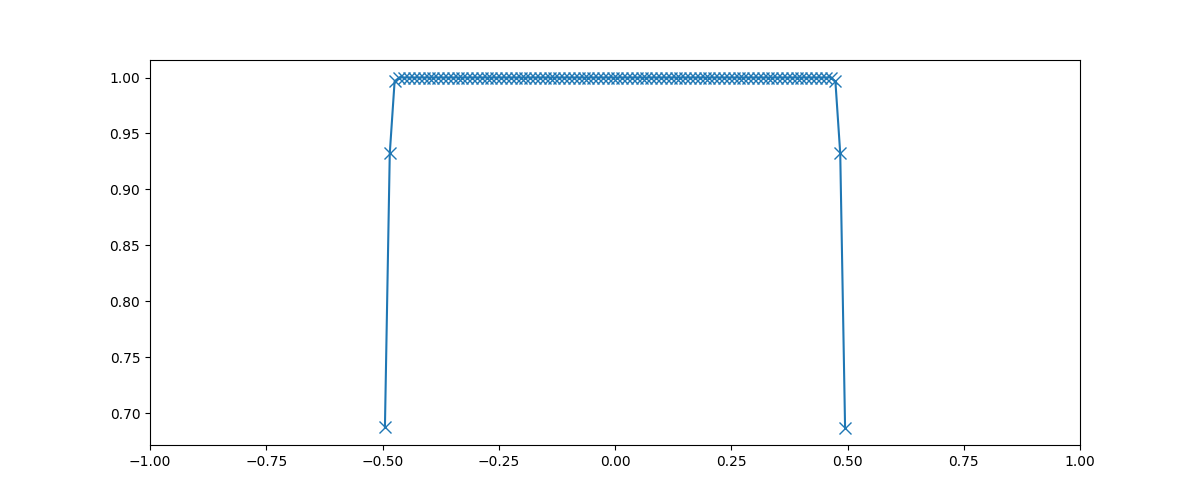

In [8]:
fig, axis = plt.subplots(1, 1, figsize=(12, 5), squeeze=False)

axis[0,0].plot(compressibleSystem.state.positions[:,0].cpu().numpy(), densities.cpu().numpy(),'x-', markersize=8)
axis[0,0].set_xlim(domain.min[0].item(), domain.max[0].item())

In [9]:

runningState = compressibleSystem.initializeNewState()

adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

In [10]:
particles = runningState.state
particles.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)

Module warpSPHCore.operations.wp_density c626317 load on device 'cuda:0' took 17.51 ms  (cached)


In [11]:
dt = config.dt
dvdt = torch.zeros_like(particles.velocities)

In [12]:
predictedVelocities = particles.velocities + dt * dvdt
# dt = config.dt

# print(f'Predicted velocities: mean: {predictedVelocities.mean().cpu().item():.6g}, min: {predictedVelocities.min().cpu().item():.6g}, max: {predictedVelocities.max().cpu().item():.6g}')

apparentArea = particles.masses / particles.densities    

# print(f'Apparent area: {apparentArea.mean().cpu().item():.6g}, min: {apparentArea.min().cpu().item():.6g}, max: {apparentArea.max().cpu().item():.6g}')

divergence = computeMomentumIncompressible(
        currentState = particles, 
        config = config, 
        schemeConfig = schemeConfig, 
        adjacency = adjacency, 
        advectionVelocities = predictedVelocities
)

rho0 = schemeConfig.fluid.restDensity
rhoStar = particles.densities + dt * divergence

# sourceTerm = config.dt * divergence
sourceTerm = (rho0 - rhoStar)# / config.dt

Module warpSPHCore.operations.wp_divergence 85ef688 load on device 'cuda:0' took 7.42 ms  (cached)


In [13]:
from warpSPH.modules.incompressible.wp_alpha import computeAlpha
from warpSPH.modules.incompressible.drift import computePressureShiftIISPH

alphas = dt**2 * computeAlpha(
        currentState = particles,
        config = config,
        schemeConfig = schemeConfig,
        adjacency = adjacency,
        apparentVolumes = apparentArea,
)

alphas = torch.clamp(alphas, max=-1e-6)  # Avoid division by zero
# print(f'Alpha: {alphas.mean().cpu().item():.6g}, min: {alphas.min().cpu().item():.6g}, max: {alphas.max().cpu().item():.6g}')


Module warpSPH.modules.incompressible.wp_alpha d6db8f0 load on device 'cuda:0' took 8.64 ms  (cached)


In [14]:
particles.pressures = torch.zeros_like(particles.densities)


In [15]:
# from warpSPHCore import *
from warpSPH.systems.compressibleMonaghan import *
from warpSPH.configurations import SimulationConfig
# from warpSPH.configurations import SimulationConfig

# from torch.profiler import profile, record_function, ProfilerActivity

def computePressureAccelIISPH(
    state: CompressibleState,
    pressureValues: torch.Tensor,
    config: SimulationConfig,
    supportScheme: SupportScheme = SupportScheme.Scatter,
    adjacency: Optional[AdjacencyList] = None):
    return -warpOperation(
        state,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Symmetric,
            supportMode = supportScheme,
        ),
        queryValues = pressureValues,
        domain = config.domain,
        adjacency=adjacency,
    ) / state.densities[:, None]


In [16]:
def computePressureShiftIISPH(
    state: CompressibleState,
    config: SimulationConfig,
    pressureAccels: torch.Tensor,
    supportScheme: SupportScheme = SupportScheme.Scatter,
    adjacency: Optional[AdjacencyList] = None,):
    kernelSum = warpOperation(
        state,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Divergence,
            gradientMode = GradientScheme.Difference,
            supportMode = SupportScheme.Scatter,
        ),
        queryValues = pressureAccels,
        domain = config.domain,
        adjacency=adjacency,
        consistentDivergence = False, # Computes fj - fi, (9) in PBSPH states fi -fj thus the minus sign
    ) #* state.densities
    return - kernelSum


In [26]:
surfaceMask = torch.zeros(particles.positions.shape[0], dtype=torch.int32, device=particles.positions.device)
particles.surfaceIndicators = surfaceMask.clone()


surfaceMask[:] = 0
surfaceMask[:5] = 1
surfaceMask[-5:] = 1


pressureA = particles.pressures.clone() * 0.
pressureB = pressureA.clone()

errors = []
pressures = []
i = 0
error = 0.
minIters = schemeConfig.solverConfig.pressureSolver.minIterations
maxIters = schemeConfig.solverConfig.pressureSolver.maxIterations
threshold = schemeConfig.solverConfig.pressureSolver.tolerance
omega = schemeConfig.solverConfig.pressureSolver.relaxationFactor
omega = 0.1

# Local anti-checkerboard stabilization (only where oscillation + residual are high).
anti_checker_beta = 0.08
anti_checker_residual_gate = 1.5

config.kernel = KernelFunctions.Wendland4
schemeConfig.pressureForceTerm = PressureForceScheme.nonConservative

pressureHistory = []

for i in range(64):
        pressureA = pressureB.clone()
        # a_p = computePressureAccelIISPH(
        #         state = particles,
        #         pressureValues = pressureA,
        #         config = config,
        #         supportScheme = SupportScheme.Scatter,
        #         adjacency = adjacency,
        # )
        particles.pressures = pressureA
        a_p = computePressureForceSurfaceAware(
                currentState = particles,
                # pressureValues = pressureA,
                config = config,
                schemeConfig = schemeConfig,
                # supportScheme = SupportScheme.Scatter,
                adjacency = adjacency,
        )
        dx_p = dt**2 * computePressureShiftIISPH(
                state = particles,
                config = config,
                pressureAccels = a_p,
                supportScheme = SupportScheme.Scatter,
                adjacency = adjacency,
        )
        
        residual = sourceTerm - dx_p
        # smoothResidual = warpOperation(
        #      queryParticles = particles,
        #      operationProperties = OperationProperties(
        #           kernel = config.kernel,
        #           operation = WarpOperation.Interpolate,
        #           supportMode = SupportScheme.Scatter,
        #      ),
        #      queryValues = residual,
        #      adjacency = adjacency,
        #      domain = config.domain,
        # )

        pressureB = pressureA + omega * residual / alphas
        # pressureB = torch.clamp(pressureB, min=0.0)  # Ensure non-negative pressures
        # pressureB = pressureB - pressureB.mean()  # Fix the pressure gauge without altering the RHS


        residual_clamped = torch.clamp(residual, min=-threshold)

        # error = torch.mean(residual_clamped).cpu().item()
        error = torch.mean(torch.abs(residual)).cpu().item()
        errors.append(error)

        pressures.append((pressureB.min().cpu().item(), pressureB.max().cpu().item(), pressureB.mean().cpu().item()))

        pressureHistory.append(pressureB.clone().cpu().numpy())
        if i >= minIters and error < threshold:
        #     print(f"Converged after {i+1} iterations with error: {error:.6g}")
            break
        
        # if verbose:
        print(f"[IS] Iteration {i+1}/{maxIters}, error: {error:.6g}, pressure min/max/mean: {pressures[-1]}")

        if len(errors) > 1 and error > errors[-2]:
            # if verbose:
            print(f"!!![IS] Warning: Error increased from {errors[-2]:.6g} to {error:.6g}.!!!")


[IS] Iteration 1/64, error: 0.007996, pressure min/max/mean: (-6.029432773590088, -0.0, -0.1760009229183197)
[IS] Iteration 2/64, error: 0.0070431, pressure min/max/mean: (-11.34555435180664, 0.0832119733095169, -0.32662078738212585)
[IS] Iteration 3/64, error: 0.00633511, pressure min/max/mean: (-16.07526206970215, 0.5182346701622009, -0.45684799551963806)
[IS] Iteration 4/64, error: 0.00571536, pressure min/max/mean: (-20.319107055664062, 1.0883370637893677, -0.570586621761322)
[IS] Iteration 5/64, error: 0.00555871, pressure min/max/mean: (-24.157215118408203, 1.7307929992675781, -0.6709049940109253)
[IS] Iteration 6/64, error: 0.00548429, pressure min/max/mean: (-27.6538028717041, 2.400879383087158, -0.7602256536483765)
[IS] Iteration 7/64, error: 0.0053736, pressure min/max/mean: (-30.860660552978516, 3.067124843597412, -0.8404709696769714)
[IS] Iteration 8/64, error: 0.00523948, pressure min/max/mean: (-33.8198127746582, 3.7077889442443848, -0.9131736755371094)
[IS] Iteration 9/6

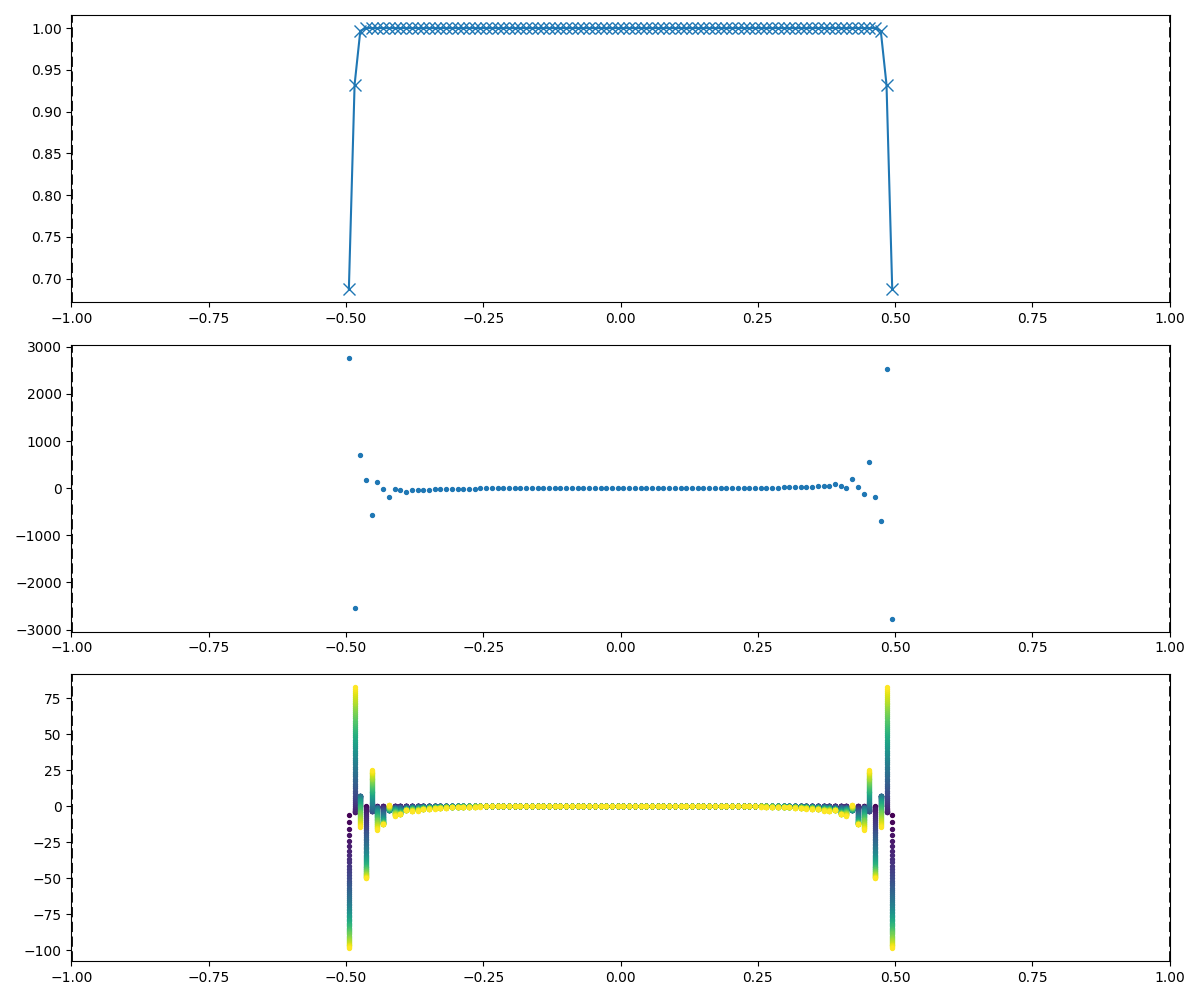

In [27]:
fig, axis = plt.subplots(3, 1, figsize=(12, 10), squeeze=False)

axis[0,0].plot(particles.positions[:,0].cpu().numpy(), particles.densities.cpu().numpy(),'x-', markersize=8)
axis[1,0].scatter(particles.positions[:,0].cpu().numpy(), a_p.cpu().numpy(), s=8)


viridisMap = plt.cm.get_cmap('viridis', len(pressureHistory))

for i, p in enumerate(pressureHistory):
    axis[2,0].scatter(particles.positions[:,0].cpu().numpy(), p, s=8, color=viridisMap(i/len(pressureHistory)))


for ax in axis.flatten():
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.axvline(x=domain.min[0].item(), color='black', linestyle='--', lw=2)
    ax.axvline(x=domain.max[0].item(), color='black', linestyle='--', lw=2)

fig.tight_layout()

In [ ]:
runningState = compressibleSystem.initializeNewState()

caseName = 'squarePatch'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
# exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
#     'frame_num': 0,
# }, **extraData))

In [ ]:
config.dt = 1e-3
schemeConfig.solverConfig.pressureSolver.tolerance = 1e-4
runningState = compressibleSystem.initializeNewState()
# runningState.state.positions = shuffleParticles(runningState.state, config, schemeConfig, 0, jitterAmount = 0.01)
runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
runningState.state.pressures = torch.zeros_like(runningState.state.densities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)

for i in tqdm(range(1)):

    config.kernel = KernelFunctions.Wendland6
    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    # config.kernel = KernelFunctions.Wendland6
    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype),
            dt = config.dt
    )
    trajectories.append((errors,pressures))
 
    dx = config.dt**2 * a_p# * 0.01
    print(f'Iterations: {len(errors)}, Incompressible Error: {errors[0]:.4g}->{errors[-1]:.4g}')
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p #runningState.state.velocities

    if torch.any(torch.isnan(runningState.state.positions)):
        print(f"NaN detected in positions at iteration {i}. Stopping simulation.")
        break


In [ ]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
axis[0,0].set_yscale('log')

In [ ]:

markerSize = 32
plotter = visualize(
    particleState = compressibleSystem.state,
    domain = config.domain,
    quantities = {
        "A": dx,
        "B": dx,
        "C": pressureB,
    },
    plotOptions = {
        "A": PlottingOptions(
            # colorMap = UniformColorMap.viridis,
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            boundaryVisualization = VisualizeOptions.Visualize,
            mapping = Mapping.x,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            # colorMap = UniformColorMap.viridis,
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            mapping = Mapping.y,
            boundaryVisualization = VisualizeOptions.Hide,
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
        "C": PlottingOptions(
            # colorMap = UniformColorMap.viridis,
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "pressures",
            # mapping = Mapping.y,
            boundaryVisualization = VisualizeOptions.Hide,
            # vMin=1e-10
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'ABC',
    figsize= (16,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi  = 300)


In [ ]:
# runningState.state.velocities[:,0] = omega * runningState.state.positions[:,1]
# runningState.state.velocities[:,1] = -omega * runningState.state.positions[:,0]

In [ ]:
# schemeConfig.solverConfig.pressureSolver.maxIterations = 32
# schemeConfig.solverConfig.pressureSolver.tolerance = 1e-4
# schemeConfig.solverConfig.divergenceFreeSolver.maxIterations = 2
schemeConfig.solverConfig

In [ ]:
nSteps = int(timeLimit / config.dt)

# runningState = compressibleSystem.initializeNewState()
# nSteps = 1500
kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if (i % 1 == 0 and i > 0) or (i == nSteps - 1):
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{timeLimit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



In [ ]:
currentState = runningState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = config.verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)
divergence = computeMomentumIncompressible(
        currentState = currentState, 
        config = config, 
        schemeConfig = schemeConfig, 
        adjacency = adjacency, 
        advectionVelocities = torch.zeros_like(currentState.velocities),
)
print("Divergence:", divergence.min(), divergence.max(), divergence.mean(), divergence.std())

In [ ]:
currentState.pressures

In [ ]:
solveDivergenceFree(
        particles = currentState, 
        config = config, 
        schemeConfig = schemeConfig, 
        adjacency = adjacency, 
        dvdt = torch.zeros_like(currentState.velocities),
        dt = config.dt,
        verbose = True
)

In [ ]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'frame_num': i,
}))

In [ ]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');